In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay, classification_report


import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv("regression_dataset.csv")

df.head()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50276.0,27.551416,5.964977,20.00,23.00,26.00,30.00,84.00
income,50276.0,66677.871151,39316.425504,4200.00,45000.00,60000.00,80000.00,1900000.00
emplyment_length,50276.0,4.866159,4.001135,0.00,2.00,4.00,7.00,150.00
loan_amount,50276.0,8887.882528,5327.333853,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,50276.0,10.258792,2.827098,5.42,7.51,10.39,12.42,22.11
loan_income_ratio,50276.0,0.145096,0.077869,0.00,0.08,0.13,0.20,0.63
credit_history_length,50276.0,5.818482,4.002464,2.00,3.00,4.00,8.00,30.00
max_allowed_loan,50276.0,81390.696913,58124.883347,232.00,49105.50,69418.50,98987.00,2638778.00


In [ ]:
x = df.drop(columns=['max_allowed_loan'])
y = df['max_allowed_loan']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
cat_cols = x_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

In [ ]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [61]:
dt1 = DecisionTreeRegressor(random_state=42)
dt1.fit(x_train, y_train)

y_pred_full = dt1.predict(x_test)

In [62]:
print("Full Tree")
print("MAE:", mean_absolute_error(y_test, y_pred_full))
print("RMSE:", root_mean_squared_error(y_test, y_pred_full))
print("R2:", r2_score(y_test, y_pred_full))

Full Tree
MAE: 1266.8939936356405
RMSE: 8203.729478560259
R2: 0.9751560781312351


In [ ]:
# Get the names from your preprocessor (replace 'preprocessor' with your actual variable name)
feature_names_list = preprocessor.get_feature_names_out()

plt.figure(figsize=(30, 15), dpi=200)

plot_tree(
    dt1,
    feature_names=feature_names_list, 
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('DT-1 Fully Grown Decision Tree Regressor')
plt.show()

In [59]:
dt2 = DecisionTreeRegressor(max_depth=4, random_state=42)
dt2.fit(x_train, y_train)

y_pred_pruned = dt2.predict(x_test)

In [60]:
print("Pruned Tree")
print("MAE:", mean_absolute_error(y_test, y_pred_pruned))
print("RMSE:", root_mean_squared_error(y_test, y_pred_pruned))
print("R2:", r2_score(y_test, y_pred_pruned))

Pruned Tree
MAE: 11755.494984836985
RMSE: 19849.146930807547
R2: 0.8545608974218094


In [ ]:
# Get the names from your preprocessor (replace 'preprocessor' with your actual variable name)
feature_names_list = preprocessor.get_feature_names_out()

plt.figure(figsize=(30, 15), dpi=200)

plot_tree(
    dt2,
    feature_names=feature_names_list, 
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('DT-1 Fully Grown Decision Tree Regressor')
plt.show()

In [69]:
# Create a dataframe for Client 60256 using only the available regression features.
client_60256 = pd.DataFrame([{
    'age': 56,
    'income': 57000,
    'emplyment_length': 15,
    'home_ownership': "RENT",
    'loan_intent': 'MEDICAL',
    'loan_amount': 25700,
    'loan_interest_rate': 23,
    'loan_income_ratio': 0.10,
    'payment_default_on_file': 'N',
    'credit_history_length': 35
}])

# Display the prepared client input row.
client_60256

,age,income,emplyment_length,home_ownership,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length
0,56,57000,15,RENT,MEDICAL,25700,23,0.1,N,35


In [70]:
client_encoded = preprocessor.transform(client_60256)

predicted_max_loan = dt1.predict(client_encoded)

print(f"Predicted Maximum Loan Amount: £{predicted_max_loan[0]:,.2f}")

Predicted Maximum Loan Amount: £87,197.00


In [9]:
df_class = pd.read_csv("classification_dataset.csv")

x_new = df_class.drop(columns=['loan_approval_status'])
y_new = df_class['loan_approval_status']

In [10]:
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(
    x_new, y_new,
    test_size=0.2,
    stratify=y_new,
    random_state=42
)

In [11]:
#Seperating the columns as numerical and categorical for scalng and encoding

num_cols_new = x_train_c.select_dtypes(include=['int64', 'float64']).columns
cat_cols_new = x_train_c.select_dtypes(include=['object']).columns

In [12]:
#Making a pipeline with both scaler and encoder and saving them as transformers
preprocessor_new = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_new),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_new)
    ]
)

In [13]:
# reuse ColumnTransformer
x_train_c = preprocessor_new.fit_transform(x_train_c)
x_test_c = preprocessor_new.transform(x_test_c)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

lr = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier(n_neighbors=9)

In [24]:
lr.fit(x_train_c, y_train_c)
knn.fit(x_train_c, y_train_c)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
estimators_list = [
    ('lr', lr),
    ('knn', knn) 
]

# Declare the ensemble (voting='soft' makes it probability-based as requested)
voting_clf = VotingClassifier(estimators=estimators_list, voting='soft')

# 3) Fit your ensemble learner
voting_clf.fit(x_train_c, y_train_c)

,estimators,"[('lr', ...), ('knn', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [26]:
def evaluate_classifier(model, X_test, y_test, model_name):
    # Predict the test labels and probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n================ {model_name} ================")
    
    # 1) Classification Report
    print(f"\n{model_name} Classification Report:")
    print(classification_report(y_test, y_pred))

    # 2) Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Approved (0)', 'Rejected (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    # 3) AUC-ROC Curve
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f'{model_name} ROC Curve')
    plt.plot([0, 1], [0, 1], color='black', linestyle='--') # Adds the random baseline
    plt.show()


================ Logistic Regression (Base Learner 1) ================

Logistic Regression (Base Learner 1) Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10056
           1       0.74      0.42      0.54      1669

    accuracy                           0.90     11725
   macro avg       0.83      0.70      0.74     11725
weighted avg       0.89      0.90      0.88     11725



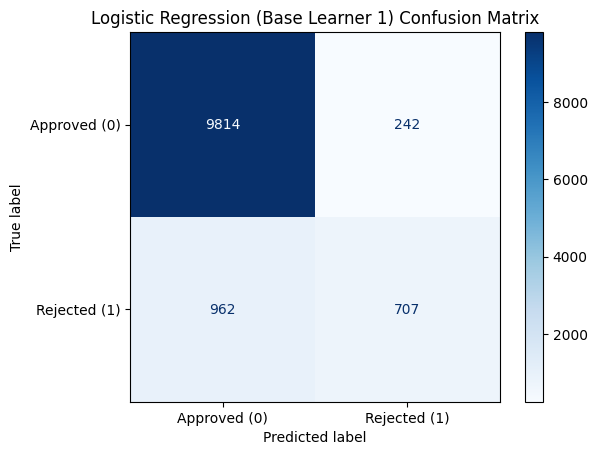

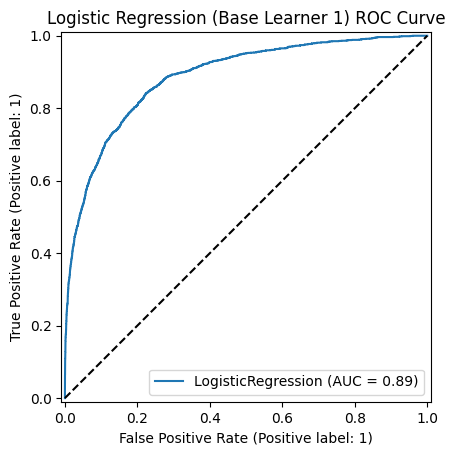


================ K-Nearest Neighbors (Base Learner 2) ================

K-Nearest Neighbors (Base Learner 2) Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96     10056
           1       0.84      0.56      0.67      1669

    accuracy                           0.92     11725
   macro avg       0.89      0.77      0.81     11725
weighted avg       0.92      0.92      0.92     11725



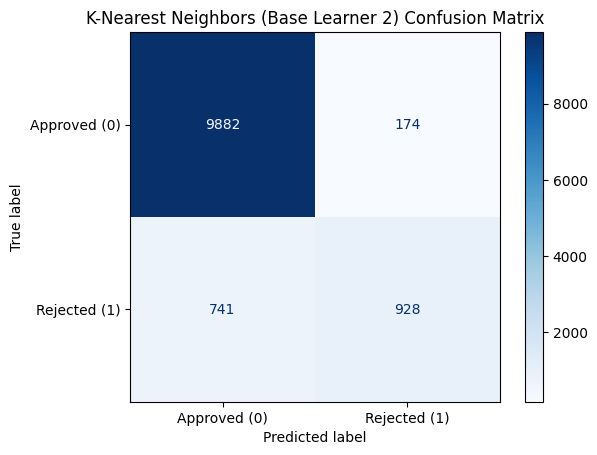

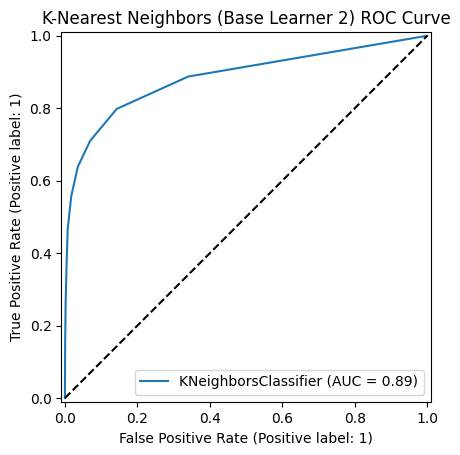


================ Voting Ensemble Learner ================

Voting Ensemble Learner Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10056
           1       0.85      0.49      0.62      1669

    accuracy                           0.92     11725
   macro avg       0.88      0.74      0.79     11725
weighted avg       0.91      0.92      0.91     11725



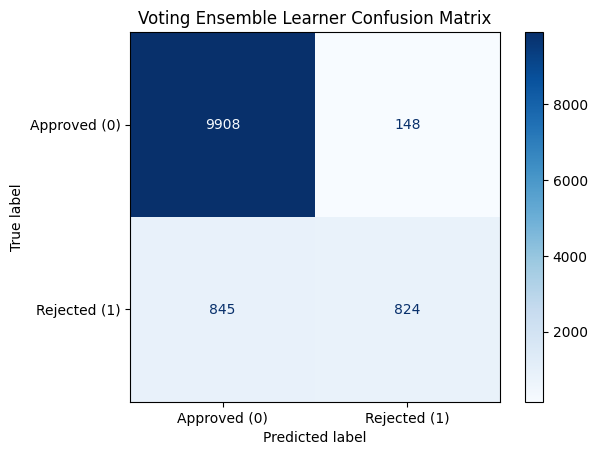

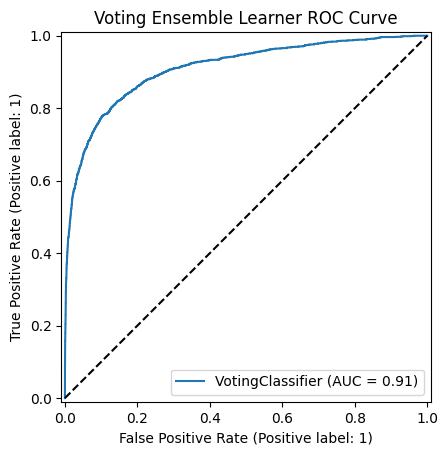

In [29]:
# Get outputs for Base Learner 1
evaluate_classifier(lr, x_test_c, y_test_c, "Logistic Regression (Base Learner 1)")

# Get outputs for Base Learner 2
evaluate_classifier(knn, x_test_c, y_test_c, "K-Nearest Neighbors (Base Learner 2)")

# Get outputs for the Ensemble
evaluate_classifier(voting_clf, x_test_c, y_test_c, "Voting Ensemble Learner")